# Percentiles
Numerical data can be sorted in increasing or decreasing order. Thus the values of a numerical data set have a *rank order*. A percentile is the value at a particular rank.

For example, if your score on a test is on the 95th percentile, a common interpretation is that only 5% of the scores were higher than yours. The median is the 50th percentile; it is commonly assumed that 50% the values in a data set are above the median.

But some care is required in giving percentiles a precise definition that works for all ranks and all lists. To see why, consider an extreme example where all the students in a class score 75 on a test. Then 75 is a natural candidate for the median, but it's not true that 50% of the scores are above 75. Also, 75 is an equally natural candidate for the 95th percentile or the 25th or any other percentile. Ties – that is, equal data values – have to be taken into account when defining percentiles.

You also have to be careful about exactly how far up the list to go when the relevant index isn't clear. For example, what should be the 87th percentile of a collection of 10 values? The 8th value of the sorted collection, or the 9th, or somewhere in between?

In this section, we will give a definition that works consistently for all ranks and all lists.

In [1]:
path_data = '../../data/'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

```{contents}
:local:
:depth: 2
```


<!-- moved-from-landing: 1100-estimation -->

## Estimation Prelude


In the previous chapter, we began to develop ways of inferential thinking. In particular, we learned how to use data to decide between two hypotheses about the world. But often we just want to know **how big** something is. 

For example, during an election year, we may want to know the percentage of voters who favor a particular candidate. To assess the current state of the economy, we might be interested in the median annual income of households in the United States.

In this chapter, we will develop a way to **estimate** an **unknown parameter**. Remember that a parameter is a numerical value associated with a population.  

To figure out the value of a parameter, we need data. If we have the relevant data for the entire population, we can simply calculate the parameter. 

However, if the population is very large – for example, if it comprises all the households in the United States – then gathering data from the entire population might be too expensive and time-consuming. In such situations, data scientists rely on **random sampling** from the population. 

This raises a question of inference: How can justifiable conclusions be drawn about the unknown parameter based on the data from the random sample? We will answer this question by using inferential thinking.

A statistic based on a random sample can be a reasonable estimate of an unknown parameter in the population. For example, you might want to use the **median annual income of sampled households as an estimate of the median annual income of all households** in the U.S.

However, the value of any statistic depends on the sample, which is based on random draws. So every time data scientists come up with an estimate based on a random sample, they are faced with a question:

**"How different could this estimate have been, if the sample had come out differently?"**

In this chapter, you will learn one way of answering this question. The answer will provide you with the tools to estimate a numerical parameter and quantify the error in your estimate.
We will start with a preliminary about percentiles. The most famous percentile is the median, often used in summaries of income data. Other percentiles will be important in the method of estimation that we are about to develop. So we will start by defining percentiles carefully.


## A Numerical Example
Before giving a general definition of all percentiles, we will define the 80th percentile of a collection of values to be the smallest value in the collection that is at least as large as 80% of all of the values.

For example, let's consider the sizes of the five largest continents – Africa, Antarctica, Asia, North America, and South America – rounded to the nearest million square miles.

In [2]:
sizes = np.array([12, 17, 6, 9, 7])

The 80th percentile is the smallest value that is at least as large as 80% of the elements of `sizes`, that is, four-fifths of the five elements. That's 12:

In [3]:
np.sort(sizes)

array([ 6,  7,  9, 12, 17])

The 80th percentile is a value on the list, namely 12. You can see that 80% of the values are **less than or equal to** it, and that it is the smallest value on the list for which this is true.

Analogously, the 70th percentile is the smallest value in the collection that is at least as large as 70% of the elements of `sizes`. Now 70% of 5 elements is "3.5 elements", so the 70th percentile is the 4th element on the list. That's 12, the same as the 80th percentile for these data.

## The `percentile` function
The numpy [`percentile`](https://numpy.org/doc/stable/reference/generated/numpy.percentile.html) function takes two arguments: a rank between 0 and 100, and an array. It returns the corresponding percentile of the array. One of the numpy percentile function parameters is `method`, the options for which include `linear` (default), `lower`, `higher`, `midpoint`, `nearest`. (*before numpy version 1.22.0, `method` is called `interpolation`.) 

[Numpy percentile](https://numpy.org/doc/stable/reference/generated/numpy.percentile.html) 
- compute the q-th percentile of the data along the specified axis; and 
- returns the q-th percentile(s) of the array elements. The syntax is:

```text
numpy.percentile(a, q, axis=None, out=None, overwrite_input=False, 
                 method='linear', keepdims=False, *, weights=None)
    Parameters:
        a : array_like of real numbers
            Input array or object that can be converted to an array.
        q : array_like of float
            Percentage or sequence of percentages for the percentiles to 
            compute. Values must be between 0 and 100 inclusive.
        method : str, optional
                 This parameter specifies the method to use for estimating 
                 the percentile.
```

In [4]:
np.percentile(sizes, 70, method='nearest')

np.int64(12)

### The General Definition ###

Let $p$ be a number between 0 and 100. The $p$th percentile of a collection is the smallest value in the collection that is at least as large as p% of all the values.

By this definition, any percentile between 0 and 100 can be computed for any collection of values, and it is always an element of the collection. 

In practical terms, suppose there are $n$ elements in the collection. To find the $p$th percentile:
- Sort the collection in increasing order.
- Find p% of n: $(p/100) \times n$; call that $k$.
- If $k$ is an integer, take the $k$th element of the sorted collection.
- If $k$ is not an integer, round it up to the next integer, and take that element of the sorted collection.

### Example ###
The table `scores_and_sections` contains one row for each student in a class of 359 students. The columns are the student's discussion section and midterm score. 

In [5]:
scores_and_sections = pd.read_csv(path_data + 'scores_by_section.csv')
scores_and_sections

,Section,Midterm
0,1,22
1,2,12
2,2,23
3,2,14
4,1,20
...,...,...
354,5,24
355,2,16
356,2,17
357,12,16


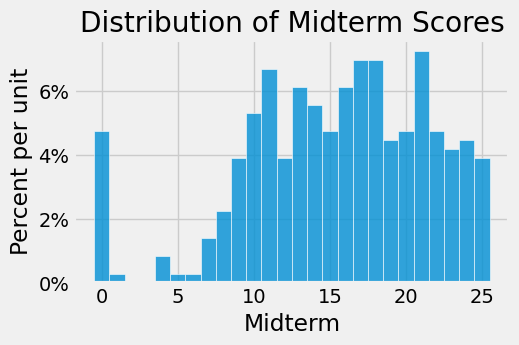

In [6]:
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(5,3))

ax.hist(
    scores_and_sections['Midterm'], 
    bins = np.arange(-0.5, 25.6, 1), 
    density=True, 
    alpha=0.8, 
    ec='white')

unit = ''
y_label = 'Percent per ' + (unit if unit else 'unit')
x_label = 'Midterm'

plt.ylabel(y_label)
plt.xlabel(x_label)
y_vals = ax.get_yticks()
# ax.set_yticklabels(['{:g}'.format(x * 100) for x in y_vals])
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0f}%'.format(y*100)))

plt.title('Distribution of Midterm Scores');
# ax.set_title('Distribution of Midterm Scores')

What was the 85th percentile of the scores? To use the `percentile` function, create an array `scores` containing the midterm scores, and find the 85th percentile:

In [7]:
scores = scores_and_sections.iloc[:,1]  ### select the second column of the DataFrame, 
                                        ### which contains the midterm scores.
scores.head()    

0    22
1    12
2    23
3    14
4    20
Name: Midterm, dtype: int64

In [8]:
# np.percentile(scores, 85, interpolation='nearest')  # nearest interpolation method is used to find the 85th percentile of the scores.
np.percentile(scores, 85, method='nearest')  # nearest interpolation method is used to find the 85th percentile of the scores.

np.int64(22)

According to the percentile function, the 85th percentile was 22. To check that this is consistent with our new definition, let's apply the definition directly.

First, put the scores in increasing order:

In [9]:
sorted_scores = np.sort(scores_and_sections.iloc[:, 1])
sorted_scores

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        1,  4,  4,  4,  5,  6,  7,  7,  7,  7,  7,  8,  8,  8,  8,  8,  8,
        8,  8,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9, 10,
       10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
       10, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 11, 11, 11, 11, 11, 11, 11, 12, 12, 12, 12, 12, 12, 12, 12, 12,
       12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
       13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 14, 14, 14, 14, 14, 14, 14,
       14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 15, 15, 15, 15,
       15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 16, 16, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17,
       17, 17, 17, 17, 17, 17, 17, 17, 17, 18, 18, 18, 18, 18, 18, 18, 18,
       18, 18, 18, 18, 18

There are 359 scores in the array. So next, find 85% of 359, which is 305.15. 

In [10]:
0.85 * 359

305.15

That's not an integer. By our definition, the 85th percentile is the 306th element of `sorted_scores`, which, by Python's indexing convention, is item 305 of the array.

In [11]:
### the 306th element of the sorted array

sorted_scores.item(305)

22

That's the same as the answer we got by using `percentile`. In future, we will just use `percentile`.

## Quartiles
The *first quartile* of a numerical collection is the 25th percentile. The terminology arises from *the first quarter*. The second quartile is the median, and the third quartile is the 75th percentile.

For our `scores` data, those values are:

In [12]:
q_25 = np.percentile(scores, 25, method='nearest').item()
q_50 = np.percentile(scores, 50, method='nearest').item()
q_75 = np.percentile(scores, 75, method='nearest').item()

print(f'25th percentile: {q_25}')
print(f'50th percentile: {q_50}')
print(f'75th percentile: {q_75}')

25th percentile: 11
50th percentile: 16
75th percentile: 20


Distributions of scores are sometimes summarized by the "middle 50%" interval, between the first and third quartiles. 


## Section Practice

Use this short exercise to check the main workflow from this section.


In [13]:
### Exercise: Compute Evidence for Percentiles
# Use the sample values below to summarize a small business metric.
# Calculate the mean and the distance between the largest and smallest values.
# Print both values.
values = [18, 21, 19, 25, 22]
### Your code starts here




### Your code ends here


In [14]:
### Solution
values = [18, 21, 19, 25, 22]
mean_value = sum(values) / len(values)
spread = max(values) - min(values)
print("Mean:", mean_value)
print("Spread:", spread)


Mean: 21.0
Spread: 7
